### <span style="color:green">**Set figure parameters**</span>
---

##### *Set figure saving parameters*

In [1]:
# save pdf figures so that text is editable in AI
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

##### *Define colors used for each CRE species and list of names*

In [314]:
colors = {'CRE001' : '#f77189',
        'CRE002' : '#f7755d',
        'CRE003' : '#e68332',
        'CRE004' : '#ce9032',
        'CRE005' : '#bb9832',
        'CRE006' : '#aa9e31',
        'CRE007' : '#97a431',
        'CRE008' : '#7eaa31',
        'CRE009' : '#50b131',
        'CRE010' : '#32b166',
        'CRE011' : '#34af84',
        'CRE012' : '#35ae96',
        'CRE013' : '#36ada4',
        'CRE014' : '#37abb1',
        'CRE015' : '#38aabf',
        'CRE016' : '#39a7d0',
        'CRE017' : '#3ba3ec',
        'CRE018' : '#7a98f4',
        'CRE019' : '#a48cf4',
        'CRE020' : '#c67df4',
        'blank1' : '#e866f4',
        'blank2' : '#f561dd',
        'blank3' : '#f668c2',
        'blank4' : '#f66ca8'}

CREs = ['CRE001', 'CRE002', 'CRE003', 'CRE004', 'CRE005', 'CRE006', 'CRE007', 'CRE008',
        'CRE009', 'CRE010', 'CRE011', 'CRE012', 'CRE013', 'CRE014', 'CRE015', 'CRE016',
        'CRE017', 'CRE018', 'CRE019', 'CRE020']

enhancers = ['E01', 'E02', 'E03', 'E04', 'E05', 'E06', 'E07', 'E08',
        'E09', 'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16',
        'E17', 'E18', 'E19', 'E20']

STARRseq = pd.read_csv(r'C:\Users\zgibbs\cellpose\RNAvsDNA.edgeR.csv')
a = STARRseq['genes'].loc[test_CREs]

CRE_names = dict(zip(CREs, a))
enhancer_names = dict(zip(CREs, enhancers))

### <span style="color:green">**Load in cell-by-gene matrices and filter to look at counts per cell**</span>
---

##### *Load cell-by-gene matrices*

In [313]:
import pandas as pd
import numpy as np

enhancer_cbg = pd.read_csv(r'C:\Users\zgibbs\cellpose\cell_by_gene\SFv4_T7_July_enhancer_cbg.csv')
T7_cbg = pd.read_csv(r'C:\Users\zgibbs\cellpose\cell_by_gene\SFv4_T7_July_T7_cbg.csv')

##### *Filter the T7 matrix to remove cells with few counts*

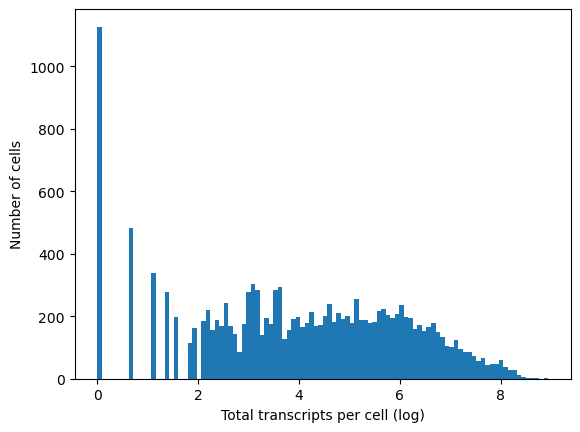

In [315]:
plt.hist(np.log(T7_cbg['total transcripts']), bins=100)
plt.xlabel('Total transcripts per cell (log)')
plt.ylabel('Number of cells')
plt.show()

In [179]:
np.exp(4)

54.598150033144236

In [316]:
# Here it looks like keeping cells with at least 10 total T7 transcripts is reasonable
T7_filt_cbg = T7_cbg[T7_cbg['total transcripts']>9]

In [317]:
T7_filt_cbg

,masks,CRE001,CRE002,CRE003,CRE004,CRE005,CRE006,CRE007,CRE008,CRE009,...,CRE013,CRE014,CRE015,CRE016,CRE017,CRE018,CRE019,CRE020,total transcripts,fov
1,10,2,14,16,8,7,3,12,15,1,...,23,1,1,1,15,13,4,7,151,"[0, 1000)"
2,11,1,2,2,2,0,1,1,2,0,...,1,0,1,1,2,0,1,2,21,"[0, 1000)"
3,12,6,14,21,11,6,4,10,9,3,...,17,2,4,2,14,8,3,6,150,"[0, 1000)"
4,13,7,35,33,16,11,3,12,22,2,...,42,2,7,5,22,21,5,11,273,"[0, 1000)"
5,14,33,51,60,58,41,28,44,71,25,...,61,7,16,14,64,37,11,29,707,"[0, 1000)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14248,224055,3,5,3,3,4,1,2,5,0,...,3,2,1,1,3,3,3,3,49,"[224000, 225000)"
14250,224057,0,5,5,2,4,0,4,4,0,...,2,0,0,0,2,1,0,1,30,"[224000, 225000)"
14251,224058,2,4,3,2,3,1,3,3,1,...,2,1,1,3,1,2,2,3,41,"[224000, 225000)"
14253,224060,7,10,9,10,14,3,10,9,3,...,13,4,5,10,11,7,11,11,171,"[224000, 225000)"


##### *Merge the two matrices based on the filtered T7 matrix*

In [318]:
# merge the enhancer and T7 counts
merged = pd.merge(T7_filt_cbg, enhancer_cbg, how='left', left_on='masks', right_on='masks')

In [319]:
# divide enhancer counts by T7 counts in merged cbg matrix to generate T7-normalized values
# '_x' represents T7 counts while '_y' represents enhancer counts
for cre in CREs:
    idx = str(cre + '_x')
    idy = str(cre + '_y')
    merged[cre] = merged[idy] / merged[idx]
    # merged[cre] = np.log2(merged[idy] / merged[idx])

In [320]:
# fill inf and nan with zeroes
merged.replace([np.inf, -np.inf], np.nan, inplace=True)
merged.fillna(0)

,masks,CRE001_x,CRE002_x,CRE003_x,CRE004_x,CRE005_x,CRE006_x,CRE007_x,CRE008_x,CRE009_x,...,CRE011,CRE012,CRE013,CRE014,CRE015,CRE016,CRE017,CRE018,CRE019,CRE020
0,10,2,14,16,8,7,3,12,15,1,...,3.00,0.75,0.304348,0.000000,5.000000,2.000000,0.533333,0.615385,0.500000,0.571429
1,11,1,2,2,2,0,1,1,2,0,...,1.00,0.00,8.000000,0.000000,1.000000,2.000000,0.500000,0.000000,2.000000,3.500000
2,12,6,14,21,11,6,4,10,9,3,...,0.00,0.20,0.470588,0.000000,1.000000,2.500000,0.214286,0.750000,0.666667,1.333333
3,13,7,35,33,16,11,3,12,22,2,...,2.50,1.00,0.309524,0.000000,1.285714,1.800000,0.272727,0.714286,0.800000,0.727273
4,14,33,51,60,58,41,28,44,71,25,...,0.50,0.72,1.229508,0.285714,1.437500,0.714286,0.484375,1.837838,1.727273,2.413793
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11143,224055,3,5,3,3,4,1,2,5,0,...,1.00,3.00,1.000000,1.000000,5.000000,6.000000,1.000000,1.666667,1.000000,1.000000
11144,224057,0,5,5,2,4,0,4,4,0,...,0.00,0.00,3.000000,0.000000,0.000000,0.000000,0.500000,11.000000,0.000000,7.000000
11145,224058,2,4,3,2,3,1,3,3,1,...,3.00,2.00,2.000000,1.000000,2.000000,1.666667,3.000000,1.500000,1.500000,1.666667
11146,224060,7,10,9,10,14,3,10,9,3,...,1.25,2.00,1.384615,1.000000,2.600000,1.800000,1.090909,3.142857,1.181818,1.909091


##### *Create 3 new dataframes for enhancer counts, T7 counts, and T7-normalized enhancer counts from the merged dataframe*

In [321]:
# T7 matrix
T7_m = merged.iloc[:,1:21]
T7_m.columns = CREs
T7_m['total transcripts'] = T7_m.sum(axis=1)
T7_m['masks'] = merged['masks']
T7_m['fov'] = pd.cut(merged.masks.astype(int), bins = np.arange(0, 226)*1000, right=False)

# enhancer matrix
CRE_m = merged.iloc[:,23:43]
CRE_m.columns = CREs
CRE_m['total transcripts'] = CRE_m.sum(axis=1)
CRE_m['masks'] = merged['masks']
CRE_m['fov'] = pd.cut(merged.masks.astype(int), bins = np.arange(0, 226)*1000, right=False)

# T7-normalized matrix
norm_m = merged.iloc[:,-20:].fillna(0)
norm_m.columns = CREs
norm_m['total transcripts'] = norm_m.sum(axis=1)
norm_m['masks'] = merged['masks']
norm_m['fov'] = pd.cut(merged.masks.astype(int), bins = np.arange(0, 226)*1000, right=False)

##### *Plot the counts for enhancer, T7, and normalized counts per cell*

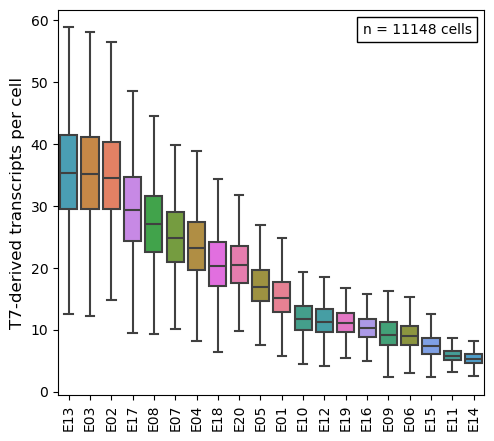

In [322]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText
import seaborn as sns

x = T7_m.groupby('fov', observed=False).mean()
sort_order = x.mean(axis=0).sort_values(ascending=False).index[2:]

fig, ax = plt.subplots(figsize=(5.5,5))
sns.boxplot([T7_m.groupby('fov', observed=False)[i].mean() for i in T7_m.columns[:20]],
           flierprops={"marker": "d", 'mfc' : 'gray'}, showfliers=False, linewidth=1.5,
            order=sort_order)
plt.xticks(np.arange(20), [enhancer_names[i] for i in sort_order], rotation=90);
ax.set_ylabel('T7-derived transcripts per cell', fontsize=12)
# ax.set_title('Estimated plasmid copy number per cell')

numcells = len(T7_m)

anchored_text = AnchoredText(f"n = {numcells} cells", loc=1)
ax.add_artist(anchored_text)

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_July_2024_analysis\T7_tpc_241003.pdf')
plt.show()

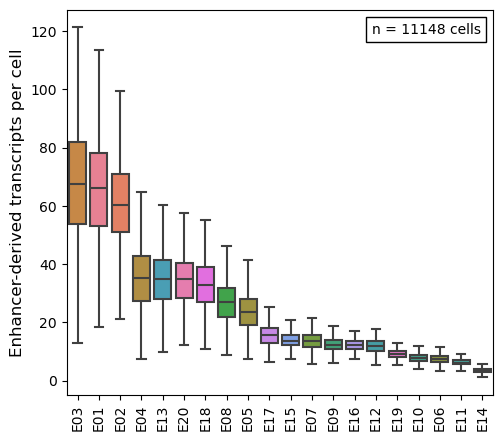

In [323]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText
import seaborn as sns

x = CRE_m.groupby('fov', observed=False).mean()
sort_order = x.mean(axis=0).sort_values(ascending=False).index[2:]

fig, ax = plt.subplots(figsize=(5.5,5))
sns.boxplot([CRE_m.groupby('fov', observed=False)[i].mean() for i in T7_m.columns[:20]],
           flierprops={"marker": "d", 'mfc' : 'gray'}, showfliers=False, linewidth=1.5,
            order=sort_order)
plt.xticks(np.arange(20), [enhancer_names[i] for i in sort_order], rotation=90);
ax.set_ylabel('Enhancer-derived transcripts per cell', fontsize=12)
# ax.set_title('Estimated plasmid copy number per cell')

numcells = len(CRE_m)

anchored_text = AnchoredText(f"n = {numcells} cells", loc=1)
ax.add_artist(anchored_text)

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_July_2024_analysis\T7_tpc_241003.pdf')
plt.show()

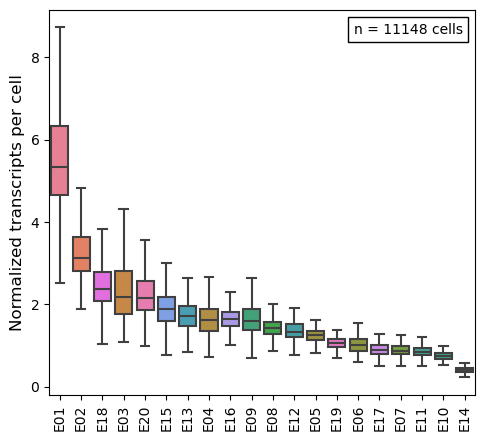

In [324]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText
import seaborn as sns

x = norm_m.groupby('fov', observed=False).mean()
sort_order = x.mean(axis=0).sort_values(ascending=False).index[2:]

fig, ax = plt.subplots(figsize=(5.5,5))
sns.boxplot([norm_m.groupby('fov', observed=False)[i].mean() for i in norm_m.columns[:20]],
           flierprops={"marker": "d", 'mfc' : 'gray'}, showfliers=False, linewidth=1.5,
            order=sort_order)
plt.xticks(np.arange(20), [enhancer_names[i] for i in sort_order], rotation=90);
ax.set_ylabel('Normalized transcripts per cell', fontsize=12)
# ax.set_title('Estimated plasmid copy number per cell')

numcells = len(norm_m)

anchored_text = AnchoredText(f"n = {numcells} cells", loc=1)
ax.add_artist(anchored_text)

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_July_2024_analysis\T7_tpc_241003.pdf')
plt.show()

In [267]:
# CRE_means = pd.DataFrame(zip(CREs,CRE_m.iloc[:,:20].median()))
# T7_means = pd.DataFrame(zip(CREs,T7_m.iloc[:,:20].median()))
# norm_means = pd.DataFrame(zip(CREs,norm_m.iloc[:,:20].mean()))
# CRE_means.columns = ['id', 'mean']
# T7_means.columns = ['id', 'mean']
# norm_means.columns = ['id', 'mean']

### <span style="color:green">**Load in other data for comparison (STARR-seq, bulk RNA-seq, nanopore sequencing for plasmid library)**</span>
---

##### *Load in original log2 fold changes from Chen et al. STARR-seq*

In [325]:
import pandas as pd

HCT116_oligos = pd.read_csv(r'C:\Users\zgibbs\cellpose\HCT116_activating_oligo.csv')

# Indices for the 20 test CREs used in STARR-FISH pilot (last 5 are yeast ORFs) from the HCT116_activating_oligos file
test_CREs = [0,11,4,7,9,137,186,323,515,642,1100,1086,1078,1073,1093,1101,1102,1103,1104,1105]

HCT116_oligos

,chr,start,end,lfc,padj
0,chr15,80003305.0,80003495.0,5.601402,3.980000e-124
1,chr15,80003185.0,80003375.0,5.445969,2.070000e-119
2,chr1,244735538.0,244735728.0,5.140302,9.600000e-111
3,chr21,33367286.0,33367476.0,5.099388,1.110000e-109
4,chr22,49384139.0,49384329.0,5.031316,1.690000e-103
...,...,...,...,...,...
1101,YFL009W_196_385,NaN,NaN,0.006862,9.663627e-01
1102,YNL186W_1584_1773,NaN,NaN,0.002139,9.842529e-01
1103,YDR490C_1052_1241,NaN,NaN,0.001636,9.862793e-01
1104,YLR138W_2138_2327,NaN,NaN,-0.001606,9.969921e-01


##### *Load in nanopore sequencing data*

In [326]:
import pandas as pd

SFv4_T7_counts = pd.read_table(r'C:\Users\zgibbs\cellpose\bulk_sequencing\plasmidsaurus_20250213\N5LC7G_2_sample_2_counts', sep='\s+', header=None, index_col=None)
SFv4_T7_counts.iloc[:, [0, 1]] = SFv4_T7_counts.iloc[:, [1, 0]]
SFv4_T7_counts.columns = ['id', 'counts']
SFv4_T7_counts['cpm'] = (SFv4_T7_counts['counts'].div(np.sum(SFv4_T7_counts['counts'])))*1000000 

C:\Users\zgibbs\AppData\Local\Temp\ipykernel_14704\772443015.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0     CRE001
1     CRE002
2     CRE003
3     CRE004
4     CRE005
5     CRE006
6     CRE007
7     CRE008
8     CRE009
9     CRE010
10    CRE011
11    CRE012
12    CRE013
13    CRE014
14    CRE015
15    CRE016
16    CRE017
17    CRE018
18    CRE019
19    CRE020
Name: 1, dtype: object' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  SFv4_T7_counts.iloc[:, [0, 1]] = SFv4_T7_counts.iloc[:, [1, 0]]


In [327]:
SFv4_T7_counts

,id,counts,cpm
0,CRE001,47348,49915.924749
1,CRE002,206662,217870.339622
2,CRE003,131420,138547.580267
3,CRE004,16133,17007.975289
4,CRE005,47419,49990.775443
5,CRE006,918,967.787846
6,CRE007,92878,97915.250038
7,CRE008,32475,34236.285719
8,CRE009,3133,3302.91865
9,CRE010,3383,3566.477431


##### *Load in bulk RNA-seq data for SFv4_T7 transfected cells*

In [328]:
# Load in featureCounts table from bulk RNA-seq sample
RNAseq1 = pd.read_csv(r'C:\Users\zgibbs\cellpose\bulk_sequencing\CRE20_20240716_rep1_featureCounts_output.txt', sep = '\t', header=1)

# Change name of last column
RNAseq1 = RNAseq1.rename(columns={'/tscc/projects/ps-renlab2/zgibbs/STARR-FISH/RNAseq/CRE20_20240716_rep1/dedup.aligned_reads.bam': 'Counts'})

# Make a new column for calculated cpm of each CRE transcript
# use the total number of reads from bulk RNA-seq sample here
RNAseq1['cpm'] = (RNAseq1['Counts'].div(30262411))*1000000 

In [329]:
RNAseq1['cpm']

0     1058.706129
1      848.973996
2     1801.178366
3      515.590116
4      419.133822
5       42.032342
6      375.812753
7      226.849077
8       48.575112
9       27.195454
10       1.189595
11      30.830326
12     894.542077
13       9.549801
14      32.746895
15      16.191704
16     203.883293
17     248.393956
18      18.703070
19     688.477861
Name: cpm, dtype: float64

### <span style="color:green">**Plot correlations**</span>
---

##### *Imaging data vs bulk RNA-seq*

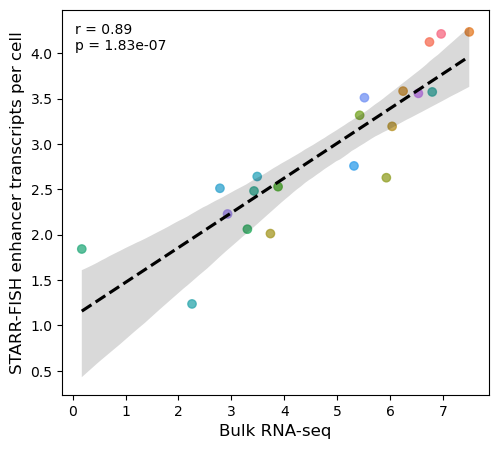

In [335]:
from matplotlib.offsetbox import AnchoredText
from scipy import stats
import seaborn as sns

fig, ax = plt.subplots(figsize=(5.5,5))

x = np.log(RNAseq1['cpm'])
# y = np.log(CRE_m.iloc[:,:20].sum())
y = np.log(CRE_m.iloc[:,:20].mean())

sns.regplot(x=x, y=y,
            color='darkolivegreen',
            line_kws={'ls' : 'dashed', 'color' : 'k'},
            scatter_kws={'color' : [colors[i] for i in CRE_means['id']]})

ax.set_ylabel('STARR-FISH enhancer transcripts per cell', fontsize=12)
ax.set_xlabel('Bulk RNA-seq', fontsize=12)

# add labels to each point on the scatter plot
# for i, txt in enumerate(CRE_means.index):
#     ax.annotate(txt, (x[i], y[i]))

stats = stats.pearsonr(x, y)

corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)

anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
ax.add_artist(anchored_text)

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_analysis\bulkRNA-seq_vs_enhancerTPC_corr_250327.pdf')
plt.show()

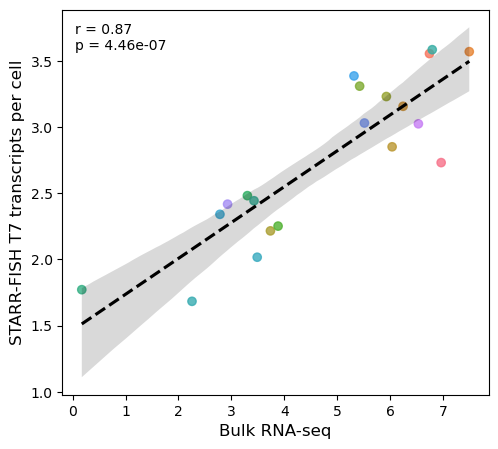

In [336]:
from matplotlib.offsetbox import AnchoredText
from scipy import stats
import seaborn as sns

fig, ax = plt.subplots(figsize=(5.5,5))

x = np.log(RNAseq1['cpm'])
# y = np.log(CRE_m.iloc[:,:20].sum())
y = np.log(T7_m.iloc[:,:20].mean())

sns.regplot(x=x, y=y,
            color='darkolivegreen',
            line_kws={'ls' : 'dashed', 'color' : 'k'},
            scatter_kws={'color' : [colors[i] for i in CRE_means['id']]})

ax.set_ylabel('STARR-FISH T7 transcripts per cell', fontsize=12)
ax.set_xlabel('Bulk RNA-seq', fontsize=12)

# add labels to each point on the scatter plot
# for i, txt in enumerate(CRE_means.index):
#     ax.annotate(txt, (x[i], y[i]))

stats = stats.pearsonr(x, y)

corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)

anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
ax.add_artist(anchored_text)

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_analysis\bulkRNA-seq_vs_T7_TPC_corr_250327.pdf')
plt.show()

##### *RNA-seq vs plasmid sequencing*

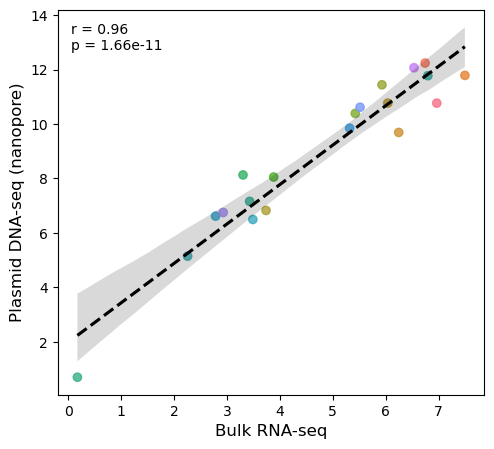

In [337]:
from matplotlib.offsetbox import AnchoredText
from scipy import stats
import seaborn as sns

fig, ax = plt.subplots(figsize=(5.5,5))

x = np.log(RNAseq1['cpm'])
# y = np.log(CRE_m.iloc[:,:20].sum())
y = np.log(SFv4_T7_counts['counts'].astype(float))

sns.regplot(x=x, y=y,
            color='darkolivegreen',
            line_kws={'ls' : 'dashed', 'color' : 'k'},
            scatter_kws={'color' : [colors[i] for i in CRE_means['id']]})

ax.set_ylabel('Plasmid DNA-seq (nanopore)', fontsize=12)
ax.set_xlabel('Bulk RNA-seq', fontsize=12)

# add labels to each point on the scatter plot
# for i, txt in enumerate(CRE_means.index):
#     ax.annotate(txt, (x[i], y[i]))

stats = stats.pearsonr(x, y)

corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)

anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
ax.add_artist(anchored_text)

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_analysis\bulkRNA-seq_vs_nanopore_corr_250307.pdf')
plt.show()

##### *"STARR-seq" vs T7-normalized STARR-FISH*

C:\Users\zgibbs\AppData\Local\Temp\ipykernel_14704\3266710400.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.annotate(txt, (x[i], y[i]))


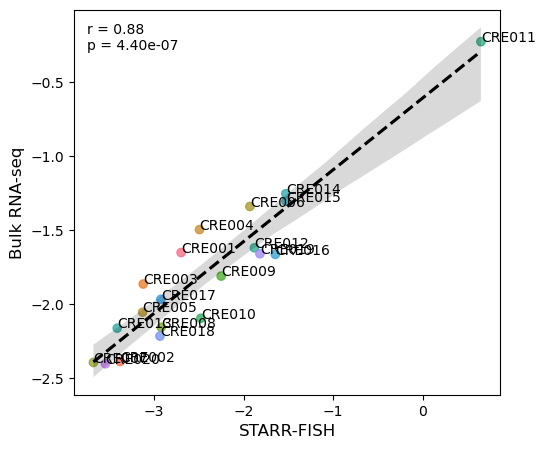

In [312]:
from matplotlib.offsetbox import AnchoredText
from scipy import stats
import seaborn as sns

fig, ax = plt.subplots(figsize=(5.5,5))

x = CRE_m.iloc[:,:20].mean() / SFv4_T7_counts['counts'].astype(float).values # calculcate log2 fold change for CRE/T7 to compare to STARR-seq

y = RNAseq1['cpm'].values / SFv4_T7_counts['counts'].astype(float).values

x, y = np.log10(x), np.log10(y)
sns.regplot(x=x, y=y,
            color='darkolivegreen',
            line_kws={'ls' : 'dashed', 'color' : 'k'},
            scatter_kws={'color' : [colors[i] for i in CRE_means['id']]})

ax.set_ylabel('Bulk RNA-seq', fontsize=12)
ax.set_xlabel('STARR-FISH', fontsize=12)

# add labels to each point on the scatter plot
for i, txt in enumerate(CRE_m.columns[:20]):
    ax.annotate(txt, (x[i], y[i]))

stats = stats.spearmanr(x, y)

corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)

anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
ax.add_artist(anchored_text)

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_analysis\log2_FC_STARR-FISH_vs_log2_FC_STARRseq_corr_250307.pdf')
plt.show()

##### *Imaging data vs plasmid sequencing*

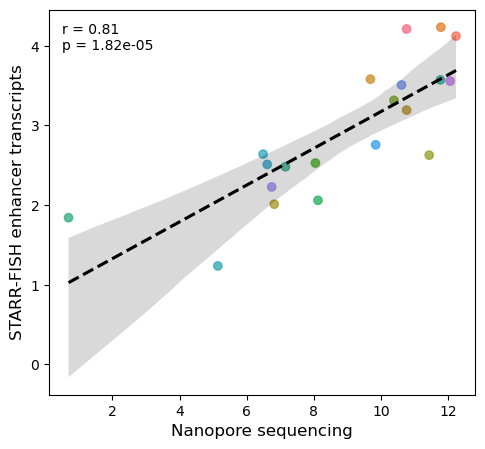

In [338]:
from matplotlib.offsetbox import AnchoredText
from scipy import stats
import seaborn as sns

fig, ax = plt.subplots(figsize=(5.5,5))

x = np.log(SFv4_T7_counts['counts'].astype(float))
y = np.log(CRE_m.iloc[:,:20].mean())

sns.regplot(x=x, y=y,
            color='darkolivegreen',
            line_kws={'ls' : 'dashed', 'color' : 'k'},
            scatter_kws={'color' : [colors[i] for i in CRE_means['id']]})

ax.set_ylabel('STARR-FISH enhancer transcripts', fontsize=12)
ax.set_xlabel('Nanopore sequencing', fontsize=12)

# add labels to each point on the scatter plot
# for i, txt in enumerate(CRE_means.index):
#     ax.annotate(txt, (x[i], y[i]))

stats = stats.pearsonr(x, y)

corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)

anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
ax.add_artist(anchored_text)

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_analysis\STARR-FISH_enhancer_tpc_vs_nanopore_250327.pdf')
plt.show()

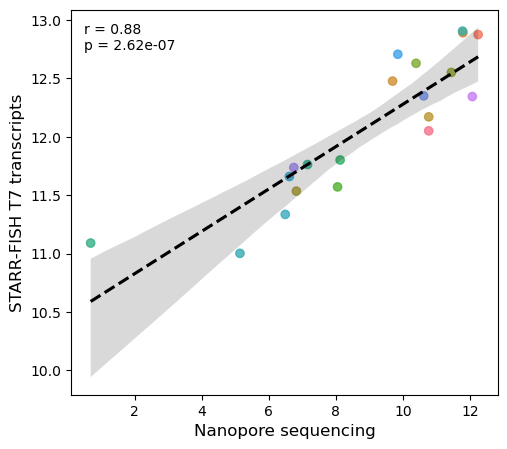

In [339]:
from matplotlib.offsetbox import AnchoredText
from scipy import stats
import seaborn as sns

fig, ax = plt.subplots(figsize=(5.5,5))

x = np.log(SFv4_T7_counts['counts'].astype(float))
y = np.log(T7_m.iloc[:,:20].sum())

sns.regplot(x=x, y=y,
            color='darkolivegreen',
            line_kws={'ls' : 'dashed', 'color' : 'k'},
            scatter_kws={'color' : [colors[i] for i in CRE_means['id']]})

ax.set_ylabel('STARR-FISH T7 transcripts', fontsize=12)
ax.set_xlabel('Nanopore sequencing', fontsize=12)

# add labels to each point on the scatter plot
# for i, txt in enumerate(CRE_means.index):
#     ax.annotate(txt, (x[i], y[i]))

stats = stats.pearsonr(x, y)

corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)

anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
ax.add_artist(anchored_text)

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_analysis\STARR-FISH_T7_tpc_vs_nanopore_250327.pdf')
plt.show()

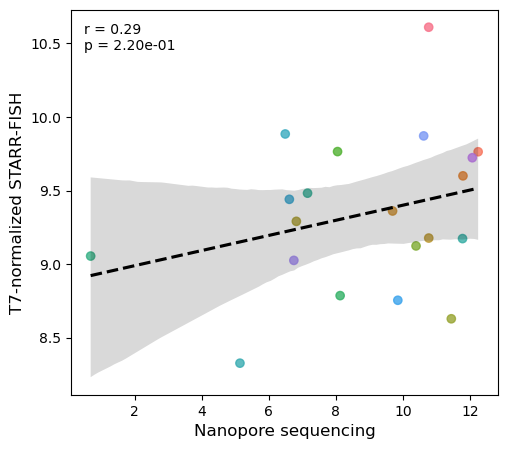

In [266]:
from matplotlib.offsetbox import AnchoredText
from scipy import stats
import seaborn as sns

fig, ax = plt.subplots(figsize=(5.5,5))

x = np.log(SFv4_T7_counts['counts'].astype(float))
y = np.log(norm_m.iloc[:,:20].sum())

sns.regplot(x=x, y=y,
            color='darkolivegreen',
            line_kws={'ls' : 'dashed', 'color' : 'k'},
            scatter_kws={'color' : [colors[i] for i in CRE_means['id']]})

ax.set_ylabel('T7-normalized STARR-FISH', fontsize=12)
ax.set_xlabel('Nanopore sequencing', fontsize=12)

# add labels to each point on the scatter plot
# for i, txt in enumerate(CRE_means.index):
#     ax.annotate(txt, (x[i], y[i]))

stats = stats.pearsonr(x, y)

corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)

anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
ax.add_artist(anchored_text)

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_analysis\log2_FC_STARR-FISH_vs_log2_FC_STARRseq_corr_250307.pdf')
plt.show()

##### *Raw STARR-seq RNA vs DNA counts from external datasets*

In [206]:
raw_starrseq = pd.read_excel(r'C:\Users\zgibbs\Downloads\mmc4.xlsx', sheet_name='raw counts HCT116')

In [213]:
raw_starrseq.iloc[:,-3:].mean(axis=1)

0         156.000000
1         909.000000
2         916.666667
3         728.666667
4        1306.000000
            ...     
14847     598.333333
14848     731.666667
14849     881.666667
14850    1150.666667
14851     945.666667
Length: 14852, dtype: float64

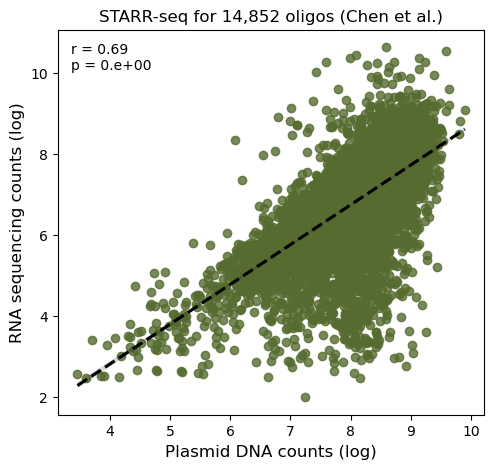

In [220]:
from matplotlib.offsetbox import AnchoredText
from scipy import stats
import seaborn as sns

fig, ax = plt.subplots(figsize=(5.5,5))

x = np.log(raw_starrseq['plasmid DNA']) # calculcate log2 fold change for CRE/T7 to compare to STARR-seq

y = np.log(raw_starrseq.iloc[:,-3:].mean(axis=1))

sns.regplot(x=x, y=y,
            color='darkolivegreen',
            line_kws={'ls' : 'dashed', 'color' : 'k'}
            )

ax.set_ylabel('RNA sequencing counts (log)', fontsize=12)
ax.set_xlabel('Plasmid DNA counts (log)', fontsize=12)
ax.set_title('STARR-seq for 14,852 oligos (Chen et al.)')

# add labels to each point on the scatter plot
# for i, txt in enumerate(CRE_means.index):
#     ax.annotate(txt, (x[i], y[i]))

stats = stats.pearsonr(x, y)

corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)

anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
ax.add_artist(anchored_text)

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_analysis\original_STARRseq_DNA_RNA_correlation.pdf')
plt.show()

In [237]:
shendure = pd.read_table(r'C:\Users\zgibbs\Downloads\GSE142696_9MPRA.ActivityRatios.tsv.gz')

In [263]:
stark = pd.read_excel(r'C:\Users\zgibbs\Downloads\1232542_arnold_som_tables\arnold_som_tables\arnold_supp_table12.xlsx')

C:\Users\zgibbs\anaconda3\envs\cellpose3\lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [264]:
stark

,Name,Chr,Start,End,Forward primer,Reverse primer
0,HS001,chr5,1950783,1951202,GGCAGCTTCACGACCTCACC,CACACCCACAGTAGAGGGCACA
1,HS002,chr22,46718833,46719436,CTCTTTCTCCCCCGTGTCCA,GAGCGCTGGAGGGACTTCTG
2,HS003,chr12,52673849,52674994,GGGGCTGGAGAGAGATGAACAC,AGAAGCCACCCGACTCACAAAG
3,HS004,chr14,70465823,70466385,CCTCCTCGTGCATGACTGTGA,CCCCATCCCCAGCTCAATTC
4,HS005,chr12,52540740,52541694,GTCTCACCTTGTCATGATTCCTCC,CAGAACTGTTTCAAGGATCCAGTGG
5,HS006,chr12,52542114,52542994,AGGGACAGCGCAGGAAGTGTGTG,GCTTCCCTGGAACAGAGATGGGGAG
6,HS007,chr12,52596773,52597831,CATGCGAGTATGCCTGTGTGTG,TGCCCAGCTCTCCTCCATAATC
7,HS008,chr12,52623914,52624780,GTCAGGTCAGTAGGTGGCTGTGGGG,AGGTGGCACACGCAAACATCCTCT
8,HS009,chr12,52545597,52546613,CTGAGTTGTGGGCAGGAGGAGT,CAAAGGATCCTCGTGTCTGAGC
9,HS010,chr12,52606980,52607854,CCCTCTACCTCCTTCCTCACAGCCC,GCTTCTCCAAGCACTCAGGGAAACAC


### <span style="color:green">**Linear regression analysis of data +/- T7 normalization**</span>
---

##### *Attempt linear regression against total transcripts per cell*

In [177]:
from scipy import stats

enhancer_rep1 = []

for cre in CRE_m.columns[:20]:
    res = stats.linregress(SFv4_T7_counts['counts'].astype(float), CRE_m[cre])
    enhancer_rep1.append(res)

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 20 and the array at index 1 has size 11148

In [13]:
from scipy import stats

enhancer_rep2 = []

for cre in enhancer_cbg_rep.columns[1:21]:
    res = stats.linregress(enhancer_cbg_rep['total transcripts'], enhancer_cbg_rep[cre])
    enhancer_rep2.append(res)

In [18]:
from scipy import stats

T7_rep1 = []

for cre in T7_cbg.columns[1:21]:
    res = stats.linregress(T7_cbg['total transcripts'], T7_cbg[cre])
    T7_rep1.append(res)

In [15]:
from scipy import stats

T7_rep2 = []

for cre in T7_cbg_rep.columns[1:21]:
    res = stats.linregress(T7_cbg_rep['total transcripts'], T7_cbg_rep[cre])
    T7_rep2.append(res)

In [19]:
from scipy import stats

norm_rep1 = []

for cre in merged_.columns[:20]:
    res = stats.linregress(merged_['total transcripts'], merged_[cre])
    norm_rep1.append(res)

In [17]:
from scipy import stats

norm_rep2 = []

for cre in merged_rep_.columns[:20]:
    res = stats.linregress(merged_rep_['total transcripts'], merged_rep_[cre])
    norm_rep2.append(res)

In [21]:
y = [enhancer_rep1[i].slope for i in range(20)]
y2 = [T7_rep1[i].slope for i in range(20)]
# y3 = [enhancer_rep2[i].slope for i in range(20)]
# y4 = [T7_rep2[i].slope for i in range(20)]
y5 = [norm_rep1[i].slope for i in range(20)]
# y6 = [norm_rep2[i].slope for i in range(20)]

In [22]:
yerr = [enhancer_rep1[i].stderr*1.96 for i in range(20)]
yerr2 = [T7_rep1[i].stderr*1.96 for i in range(20)]
# yerr3 = [enhancer_rep2[i].stderr*1.96 for i in range(20)]
# yerr4 = [T7_rep2[i].stderr*1.96 for i in range(20)]
yerr5 = [norm_rep1[i].stderr*1.96 for i in range(20)]
# yerr6 = [norm_rep2[i].stderr*1.96 for i in range(20)]

In [23]:
enhancer_full_rep1 = pd.DataFrame(list(zip(enhancer_cbg.columns[1:21], y, yerr)), columns = ['id', 'score', 'stderr'])
T7_full_rep1 = pd.DataFrame(list(zip(T7_cbg.columns[1:21], y2, yerr2)), columns = ['id', 'score', 'stderr'])
# enhancer_full_rep2 = pd.DataFrame(list(zip(enhancer_cbg_rep.columns[1:21], y3, yerr3)), columns = ['id', 'score', 'stderr'])
# T7_full_rep2 = pd.DataFrame(list(zip(T7_cbg_rep.columns[1:21], y4, yerr4)), columns = ['id', 'score', 'stderr'])
norm_full_rep1 = pd.DataFrame(list(zip(enhancer_cbg.columns[1:21], y5, yerr5)), columns = ['id', 'score', 'stderr'])
# norm_full_rep2 = pd.DataFrame(list(zip(enhancer_cbg_rep.columns[1:21], y6, yerr6)), columns = ['id', 'score', 'stderr'])

In [25]:
enhancer_full_rep1_s = enhancer_full_rep1.sort_values('score', axis=0, ascending=False)
T7_full_rep1_s = T7_full_rep1.sort_values('score', axis=0, ascending=False)
# enhancer_full_rep2_s = enhancer_full_rep2.sort_values('score', axis=0, ascending=False)
# T7_full_rep2_s = T7_full_rep2.sort_values('score', axis=0, ascending=False)
norm_full_rep1_s = norm_full_rep1.sort_values('score', axis=0, ascending=False)
# norm_full_rep2_s = norm_full_rep2.sort_values('score', axis=0, ascending=False)

In [26]:
# plotcomps = {'enhancer_full_rep1_s':enhancer_full_rep1_s, 'T7_full_rep1_s':T7_full_rep1_s, 'norm_full_rep1_s':norm_full_rep1_s,
#              'enhancer_full_rep2_s':enhancer_full_rep2_s, 'T7_full_rep2_s':T7_full_rep2_s, 'norm_full_rep2_s':norm_full_rep2_s}

plotcomps = {'enhancer_full_rep1_s':enhancer_full_rep1_s, 'T7_full_rep1_s':T7_full_rep1_s, 'norm_full_rep1_s':norm_full_rep1_s}

In [27]:
norm_full_rep1_s

,id,score,stderr
2,CRE003,0.148154,0.001910
4,CRE005,0.122726,0.001928
0,CRE001,0.117379,0.001334
12,CRE013,0.101904,0.001283
17,CRE018,0.074577,0.000968
3,CRE004,0.060352,0.000773
1,CRE002,0.059721,0.000837
19,CRE020,0.054941,0.001103
6,CRE007,0.041525,0.000523
5,CRE006,0.041051,0.001502


##### Plot the T7 and enhancer activity (regression) scores +/- normalization

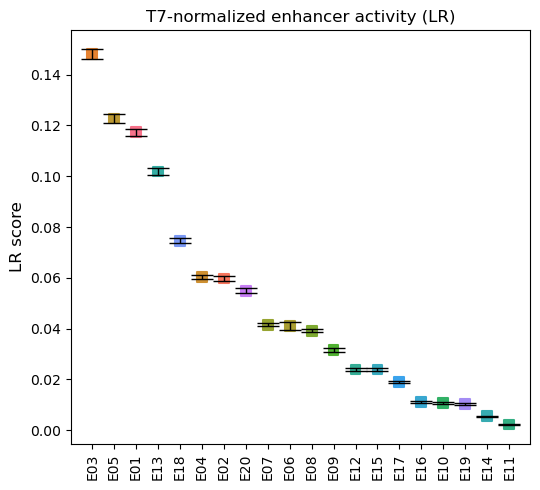

In [29]:
fig, ax = plt.subplots(figsize=(5.5,5))

ax.scatter(np.arange(20), norm_full_rep1_s['score'], marker='s', c=[colors[idx] for idx in norm_full_rep1_s['id']], s=50, lw=1.5)
ax.errorbar(np.arange(20), norm_full_rep1_s['score'], norm_full_rep1_s['stderr'], linestyle='', linewidth=1, capsize=8, mew=1, ecolor='k')

ax.set_xticks(np.arange(20))
ax.set_ylabel('LR score', fontsize=12)
ax.set_title('T7-normalized enhancer activity (LR)')
ax.set_xlabel(None)
ax.set_xticklabels([enhancer_names[idx] for idx in norm_full_rep1_s['id']], rotation=90)

plt.tight_layout()
# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_July_2024_analysis\enhancer_LR_with_T7_normalization_250131.pdf')

plt.show()

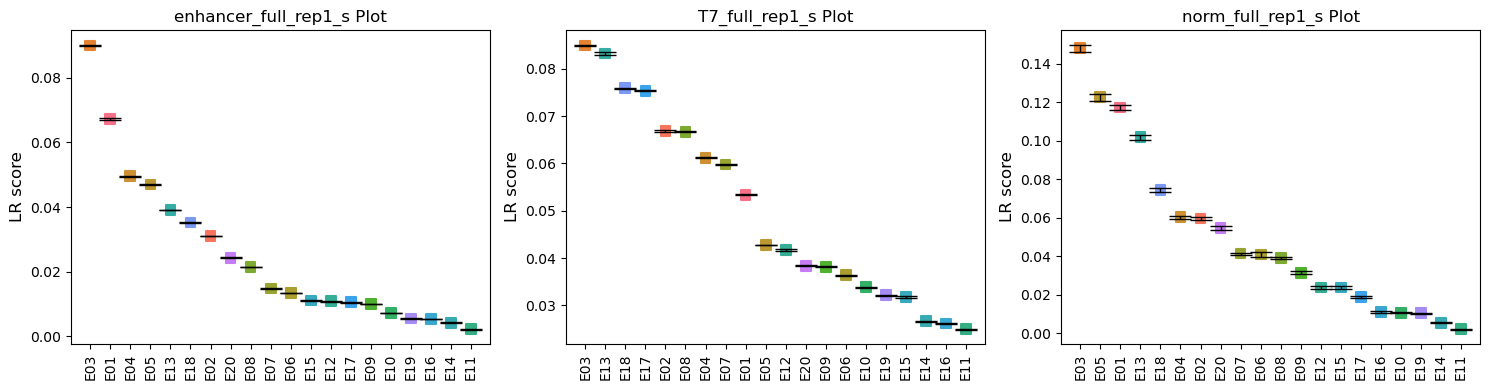

In [33]:
# Plot the enhancer activity scores in a descending order

import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText

fig, ax = plt.subplots(1, 3, figsize=(15,4))

# Flatten the ax array to easily loop through each subplot
ax = ax.flatten()

for i, (name, df) in enumerate(plotcomps.items()):
    # Plot on the i-th subplot
    ax[i].scatter(np.arange(20), df['score'], marker='s', c=[colors[idx] for idx in df['id']], s=50, lw=1.5)
    ax[i].errorbar(np.arange(20), df['score'], df['stderr'], linestyle='', linewidth=1, capsize=8, mew=1, ecolor='k')
    
    ax[i].set_xticks(np.arange(20))
    ax[i].set_ylabel('LR score', fontsize=12)
    ax[i].set_title(f"{name} Plot")
    ax[i].set_xlabel(None)
    ax[i].set_xticklabels([enhancer_names[idx] for idx in df['id']], rotation=90)

    # numcells = len(df)
    # anchored_text = AnchoredText(f"n = {numcells} cells", loc=1)
    # ax[i].add_artist(anchored_text)

plt.tight_layout()
# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_July_2024_analysis\activity_no_T7_normalization_241003.pdf')
plt.show()

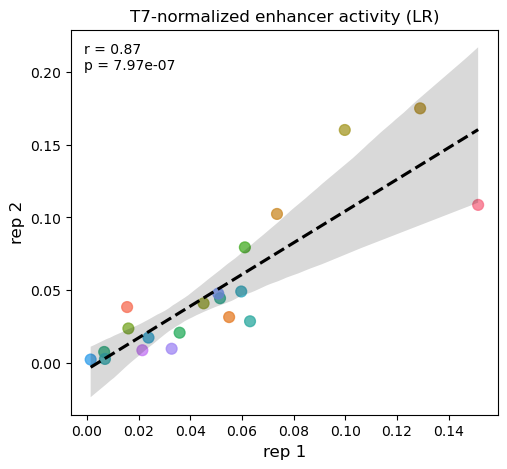

In [208]:
# plot the correlation between linear regression scores

import seaborn as sns
from scipy import stats

fig, ax = plt.subplots(figsize=(5.5,5))

x = norm_full_rep1['score']
y = norm_full_rep2['score']

# sns.set_palette("viridis")

sns.regplot(x=x, y=y,
            scatter_kws={'color' : [colors[i] for i in norm_full_rep1['id']], 's' : 60},
            line_kws={'ls' : 'dashed', 'color' : 'k'})

ax.set_ylabel('rep 2', fontsize=12)
ax.set_xlabel('rep 1', fontsize=12)
ax.set_title('T7-normalized enhancer activity (LR)')

stats = stats.pearsonr(x, y)

corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)

anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
ax.add_artist(anchored_text)

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_Sept_2024_analysis\T7_normalized_enhancer_LR_reps_pearson_corr_250131.pdf')
plt.show()

C:\Users\zgibbs\AppData\Local\Temp\ipykernel_31516\1312425910.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x = np.nanmean([merged_.groupby('fov')[i].mean() for i in merged_.columns[:-3]], axis=1)
C:\Users\zgibbs\AppData\Local\Temp\ipykernel_31516\1312425910.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  y = np.nanmean([merged_rep_.groupby('fov')[i].mean() for i in merged_rep_.columns[:-3]], axis=1)


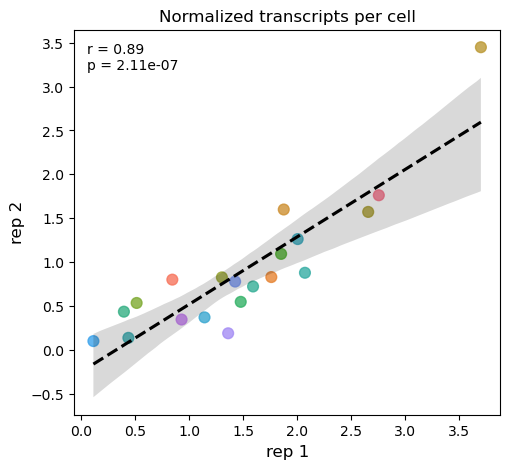

In [164]:
# plot the correlation between normalized transcripts per cell (no regression)

import seaborn as sns
from scipy import stats

fig, ax = plt.subplots(figsize=(5.5,5))

x = np.nanmean([merged_.groupby('fov')[i].mean() for i in merged_.columns[:-3]], axis=1)
y = np.nanmean([merged_rep_.groupby('fov')[i].mean() for i in merged_rep_.columns[:-3]], axis=1)

sns.regplot(x=x, y=y,
            scatter_kws={'color' : [colors[i] for i in merged_.columns[:-3]], 's' : 60},
            line_kws={'ls' : 'dashed', 'color' : 'k'})

ax.set_ylabel('rep 2', fontsize=12)
ax.set_xlabel('rep 1', fontsize=12)
ax.set_title('Normalized transcripts per cell')

stats = stats.pearsonr(x, y)

corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)

anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
ax.add_artist(anchored_text)

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_Sept_2024_analysis\enhancer_tpc_normalized_reps_pearson_corr_241003.pdf')
plt.show()

### <span style="color:green">**Subsampling the T7-normalized data**</span>
---

##### *Subsample the data*

In [193]:
import pandas as pd
import numpy as np

# Parameters
n_subsamples = 500  # Number of subsamples
subsample_size = 5000  # Size of each subsample

# List to store statistics for each subsample
results = []

# Subsampling loop
for i in range(n_subsamples):
    # Randomly sample without replacement
    subsample = merged_.iloc[:,:20].sample(n=subsample_size, random_state=i)
    
    # Calculate statistics for each column
    stats = {'subsample': i+1}  # Include the subsample number
    
    for col in merged_.columns[:20]:
        # Calculate mean for each column
        mean = subsample[col].mean()
        
        # Store statistics for the column
        stats[col] = mean

    # Append the results for this subsample
    results.append(stats)

# Convert the results into a DataFrame
stats_df = pd.DataFrame(results)
std_dev = stats_df.iloc[:,1:].std()
avg =  stats_df.iloc[:,1:].mean()
cv = std_dev / avg

# Add final stats to dataframe

stats_df.loc['avg'] = avg
stats_df.loc['std_dev'] = std_dev
stats_df.loc['cv'] = cv
df5000 = stats_df

df5000 = df5000.sort_values('avg', axis=1, ascending=False)
# Display the DataFrame
df5000

,CRE005,CRE001,CRE006,CRE013,CRE015,CRE004,CRE009,CRE003,CRE012,CRE010,...,CRE019,CRE007,CRE016,CRE020,CRE002,CRE008,CRE014,CRE011,CRE017,subsample
0,3.729741,2.770390,2.648028,2.063935,1.995531,1.894832,1.856737,1.788966,1.582305,1.507962,...,1.360864,1.307809,1.149726,0.926367,0.842273,0.516503,0.430050,0.394447,0.110399,1.0
1,3.673280,2.794244,2.711334,2.080914,1.976212,1.829695,1.826290,1.793441,1.581152,1.466572,...,1.328155,1.306099,1.131594,0.935735,0.845601,0.524375,0.438410,0.395316,0.113021,2.0
2,3.677840,2.777155,2.610399,2.047692,1.995817,1.880913,1.852907,1.792051,1.579924,1.506266,...,1.373050,1.288598,1.152011,0.935526,0.839392,0.517358,0.435292,0.396862,0.112983,3.0
3,3.647526,2.698525,2.609349,2.082725,2.026388,1.837841,1.837965,1.743652,1.569407,1.486053,...,1.367599,1.309757,1.144256,0.922574,0.856243,0.531877,0.440570,0.393600,0.112117,4.0
4,3.704051,2.842914,2.687008,2.092508,2.013182,1.917956,1.884510,1.765174,1.605824,1.461251,...,1.379569,1.348779,1.175351,0.910713,0.843011,0.512029,0.429625,0.389079,0.110327,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,3.768037,2.763980,2.679227,2.056749,1.990482,1.853657,1.839779,1.784075,1.583394,1.465832,...,1.349358,1.322073,1.144873,0.956193,0.854880,0.525890,0.435418,0.391369,0.114511,499.0
499,3.805026,2.770389,2.707891,2.075385,2.019443,1.849338,1.868851,1.798797,1.603643,1.458145,...,1.356760,1.267372,1.122145,0.924243,0.846503,0.520143,0.429561,0.398918,0.111360,500.0
avg,3.699601,2.755633,2.653831,2.068882,2.002995,1.871618,1.846025,1.763710,1.590102,1.473691,...,1.359477,1.301386,1.139829,0.929509,0.844205,0.514499,0.435950,0.394626,0.112909,NaN
std_dev,0.056088,0.056355,0.041058,0.027604,0.024706,0.027078,0.024719,0.028983,0.019581,0.019950,...,0.017952,0.018130,0.013174,0.012448,0.009050,0.008933,0.005661,0.006018,0.002208,NaN


In [194]:
import pandas as pd
import numpy as np

# Parameters
n_subsamples = 500  # Number of subsamples
subsample_size = 2500  # Size of each subsample

# List to store statistics for each subsample
results = []

# Subsampling loop
for i in range(n_subsamples):
    # Randomly sample without replacement
    subsample = merged_.iloc[:,:20].sample(n=subsample_size, random_state=i)
    
    # Calculate statistics for each column
    stats = {'subsample': i+1}  # Include the subsample number
    
    for col in merged_.columns[:20]:
        # Calculate mean for each column
        mean = subsample[col].mean()
        
        # Store statistics for the column
        stats[col] = mean

    # Append the results for this subsample
    results.append(stats)

# Convert the results into a DataFrame
stats_df = pd.DataFrame(results)
std_dev = stats_df.iloc[:,1:].std()
avg =  stats_df.iloc[:,1:].mean()
cv = std_dev / avg

# Add final stats to dataframe
stats_df.loc['avg'] = avg
stats_df.loc['std_dev'] = std_dev
stats_df.loc['cv'] = cv
df2500 = stats_df

df2500 = df2500.sort_values('avg', axis=1, ascending=False)
# Display the DataFrame
df2500

,CRE005,CRE001,CRE006,CRE013,CRE015,CRE004,CRE009,CRE003,CRE012,CRE010,...,CRE019,CRE007,CRE016,CRE020,CRE002,CRE008,CRE014,CRE011,CRE017,subsample
0,3.782476,2.774160,2.646570,2.045466,1.993097,1.934694,1.888071,1.827813,1.588435,1.483478,...,1.361276,1.321686,1.166738,0.934459,0.841668,0.515859,0.419487,0.400895,0.107733,1.0
1,3.735693,3.054208,2.787426,2.089154,1.997393,1.915844,1.876222,1.885219,1.612135,1.502241,...,1.374905,1.331368,1.125747,0.957215,0.856298,0.527921,0.441663,0.405098,0.115179,2.0
2,3.620167,2.784108,2.658061,2.050672,1.982987,1.838677,1.831386,1.750455,1.593031,1.518366,...,1.376718,1.276323,1.187169,0.946353,0.843913,0.516531,0.451049,0.400044,0.113587,3.0
3,3.510563,2.512996,2.501048,2.030580,1.973658,1.773055,1.801890,1.718291,1.560445,1.481500,...,1.354398,1.265110,1.137591,0.910803,0.853333,0.528394,0.425344,0.391255,0.116356,4.0
4,3.595972,2.748186,2.742318,2.101400,2.065085,1.818284,1.914583,1.738779,1.634204,1.444432,...,1.370456,1.333310,1.161620,0.917148,0.848816,0.515857,0.430436,0.388476,0.105190,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,3.785332,2.727354,2.705654,2.034307,1.976183,1.856431,1.834494,1.828276,1.555607,1.495974,...,1.334163,1.352717,1.146353,0.975442,0.868921,0.543510,0.440408,0.385889,0.118404,499.0
499,3.801258,2.909776,2.807542,2.090387,2.051157,1.857641,1.931281,1.817307,1.642394,1.444278,...,1.396189,1.302401,1.144103,0.916279,0.844703,0.509130,0.434544,0.410458,0.113633,500.0
avg,3.699036,2.757610,2.655328,2.069979,2.003193,1.873820,1.845453,1.764689,1.590886,1.473358,...,1.359493,1.301232,1.140078,0.930903,0.844527,0.514922,0.435980,0.394240,0.112911,NaN
std_dev,0.095153,0.096698,0.073877,0.048926,0.042535,0.045547,0.042923,0.051962,0.035484,0.034956,...,0.031411,0.032434,0.022832,0.021600,0.017388,0.015690,0.009694,0.010858,0.004119,NaN


In [195]:
import pandas as pd
import numpy as np

# Parameters
n_subsamples = 500  # Number of subsamples
subsample_size = 1000  # Size of each subsample

# List to store statistics for each subsample
results = []

# Subsampling loop
for i in range(n_subsamples):
    # Randomly sample without replacement
    subsample = merged_.iloc[:,:20].sample(n=subsample_size, random_state=i)
    
    # Calculate statistics for each column
    stats = {'subsample': i+1}  # Include the subsample number
    
    for col in merged_.columns[:20]:
        # Calculate mean for each column
        mean = subsample[col].mean()
        
        # Store statistics for the column
        stats[col] = mean

    # Append the results for this subsample
    results.append(stats)

# Convert the results into a DataFrame
stats_df = pd.DataFrame(results)
std_dev = stats_df.iloc[:,1:].std()
avg =  stats_df.iloc[:,1:].mean()
cv = std_dev / avg

# Add final stats to dataframe
stats_df.loc['avg'] = avg
stats_df.loc['std_dev'] = std_dev
stats_df.loc['cv'] = cv
df1000 = stats_df

df1000 = df1000.sort_values('avg', axis=1, ascending=False)
# Display the DataFrame
df1000

,CRE005,CRE001,CRE006,CRE013,CRE015,CRE004,CRE009,CRE003,CRE012,CRE010,...,CRE019,CRE007,CRE016,CRE020,CRE002,CRE008,CRE014,CRE011,CRE017,subsample
0,3.602017,2.782133,2.569617,2.091508,1.905684,1.817154,1.872994,1.909031,1.555805,1.477152,...,1.335543,1.278888,1.155680,0.925162,0.844105,0.511428,0.408878,0.389078,0.110076,1.0
1,3.769715,3.136292,2.753008,2.063387,1.921884,1.804316,1.814672,1.916861,1.647857,1.477751,...,1.294155,1.342413,1.095830,0.941778,0.821919,0.504124,0.447036,0.395229,0.115743,2.0
2,3.601978,2.697687,2.478665,1.972463,1.904956,1.831723,1.833320,1.640886,1.571974,1.418305,...,1.295591,1.205614,1.169649,0.898639,0.825730,0.478772,0.427291,0.370201,0.105382,3.0
3,3.503256,2.345255,2.589643,2.029257,2.060254,1.737834,1.797899,1.735294,1.574959,1.532508,...,1.427327,1.290847,1.142488,0.849152,0.823626,0.511052,0.422635,0.385744,0.107745,4.0
4,3.536834,2.563297,2.872019,2.108754,2.029568,1.761512,1.838297,1.659785,1.694954,1.439701,...,1.407199,1.372920,1.183294,0.958059,0.857992,0.524063,0.433124,0.396630,0.103831,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,3.768545,2.920414,2.705757,2.038541,1.945771,1.946242,1.816791,1.716803,1.560655,1.523545,...,1.383760,1.412893,1.175526,0.987846,0.842473,0.539688,0.455882,0.396386,0.120609,499.0
499,3.750800,2.840787,2.763957,2.132049,2.050880,1.827572,1.862825,1.875583,1.603396,1.450974,...,1.377737,1.330201,1.140045,0.948999,0.849482,0.511841,0.465567,0.428404,0.118342,500.0
avg,3.699919,2.765618,2.664695,2.070724,2.005912,1.879415,1.853014,1.765884,1.597629,1.475747,...,1.359205,1.304055,1.140722,0.932436,0.844636,0.514485,0.436359,0.395678,0.112833,NaN
std_dev,0.160687,0.163432,0.127283,0.090436,0.078682,0.079451,0.079676,0.092497,0.064647,0.059617,...,0.053969,0.053026,0.040125,0.037766,0.029665,0.029003,0.018003,0.019628,0.006984,NaN


In [196]:
import pandas as pd
import numpy as np

# Parameters
n_subsamples = 500  # Number of subsamples
subsample_size = 500  # Size of each subsample

# List to store statistics for each subsample
results = []

# Subsampling loop
for i in range(n_subsamples):
    # Randomly sample without replacement
    subsample = merged_.iloc[:,:20].sample(n=subsample_size, random_state=i)
    
    # Calculate statistics for each column
    stats = {'subsample': i+1}  # Include the subsample number
    
    for col in merged_.columns[:20]:
        # Calculate mean for each column
        mean = subsample[col].mean()
        
        # Store statistics for the column
        stats[col] = mean

    # Append the results for this subsample
    results.append(stats)

# Convert the results into a DataFrame
stats_df = pd.DataFrame(results)
std_dev = stats_df.iloc[:,1:].std()
avg =  stats_df.iloc[:,1:].mean()
cv = std_dev / avg

# Add final stats to dataframe
stats_df.loc['avg'] = avg
stats_df.loc['std_dev'] = std_dev
stats_df.loc['cv'] = cv
df500 = stats_df

df500 = df500.sort_values('avg', axis=1, ascending=False)
# Display the DataFrame
df500

,CRE005,CRE001,CRE006,CRE013,CRE015,CRE004,CRE009,CRE003,CRE012,CRE010,...,CRE019,CRE007,CRE016,CRE020,CRE002,CRE008,CRE014,CRE011,CRE017,subsample
0,3.647706,2.591506,2.499330,2.116124,1.942452,1.707693,1.866162,1.986075,1.555444,1.537952,...,1.429147,1.269398,1.166243,0.979912,0.819011,0.523382,0.415579,0.409837,0.107953,1.0
1,3.676487,3.485097,2.685718,2.072653,1.891790,1.738404,1.870456,1.850561,1.663781,1.408385,...,1.325073,1.349838,1.056000,0.881206,0.835619,0.489687,0.409131,0.399371,0.099673,2.0
2,3.563189,2.532701,2.453138,2.036836,1.902928,1.917893,1.771919,1.748446,1.565317,1.439654,...,1.279875,1.200275,1.181491,0.946048,0.872717,0.511381,0.402766,0.342011,0.105127,3.0
3,3.765784,2.462578,2.647179,2.096150,2.063301,1.869849,1.849908,1.754264,1.640679,1.564931,...,1.473077,1.300572,1.194906,0.828821,0.788686,0.466014,0.419639,0.392727,0.089876,4.0
4,3.128534,2.451152,2.813527,2.043697,2.032484,1.673502,1.776435,1.683700,1.720300,1.399228,...,1.412546,1.348369,1.127982,0.926745,0.861221,0.545718,0.444510,0.389151,0.108572,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,3.897509,2.983406,2.914815,2.207360,2.172034,2.062518,2.030923,1.884131,1.688656,1.437035,...,1.414784,1.478060,1.168309,1.039211,0.910072,0.570723,0.451489,0.406718,0.118361,499.0
499,3.897964,2.737509,2.573926,1.976141,1.965822,1.893615,1.817542,1.677995,1.595416,1.430181,...,1.370462,1.285504,1.185045,0.939971,0.825009,0.485436,0.473919,0.407038,0.113766,500.0
avg,3.707628,2.770744,2.652411,2.067607,2.005412,1.883966,1.850317,1.774103,1.593978,1.472318,...,1.359737,1.301691,1.137012,0.931365,0.844330,0.515372,0.435426,0.394740,0.112501,NaN
std_dev,0.234953,0.254656,0.186816,0.123989,0.112322,0.120195,0.120177,0.138693,0.094870,0.085782,...,0.079497,0.076449,0.056229,0.053521,0.042114,0.040634,0.025870,0.027705,0.009747,NaN


In [197]:
import pandas as pd
import numpy as np

# Parameters
n_subsamples = 500  # Number of subsamples
subsample_size = 250  # Size of each subsample

# List to store statistics for each subsample
results = []

# Subsampling loop
for i in range(n_subsamples):
    # Randomly sample without replacement
    subsample = merged_.iloc[:,:20].sample(n=subsample_size, random_state=i)
    
    # Calculate statistics for each column
    stats = {'subsample': i+1}  # Include the subsample number
    
    for col in merged_.columns[:20]:
        # Calculate mean for each column
        mean = subsample[col].mean()
        
        # Store statistics for the column
        stats[col] = mean

    # Append the results for this subsample
    results.append(stats)

# Convert the results into a DataFrame
stats_df = pd.DataFrame(results)
std_dev = stats_df.iloc[:,1:].std()
avg =  stats_df.iloc[:,1:].mean()
cv = std_dev / avg

# Add final stats to dataframe
stats_df.loc['avg'] = avg
stats_df.loc['std_dev'] = std_dev
stats_df.loc['cv'] = cv
df250 = stats_df

df250 = df250.sort_values('avg', axis=1, ascending=False)
# Display the DataFrame
df250

,CRE005,CRE001,CRE006,CRE013,CRE015,CRE004,CRE009,CRE003,CRE012,CRE010,...,CRE019,CRE007,CRE016,CRE020,CRE002,CRE008,CRE014,CRE011,CRE017,subsample
0,3.556485,2.511980,2.335695,2.057656,1.947938,1.586132,1.833425,1.964165,1.458349,1.616960,...,1.462982,1.184106,1.134551,0.945621,0.797332,0.504194,0.414246,0.443509,0.104689,1.0
1,3.408136,4.167603,2.600509,2.127998,1.904585,1.820996,1.963172,1.867406,1.593052,1.580560,...,1.398065,1.473930,1.102880,0.931287,0.863964,0.540458,0.458989,0.398137,0.107656,2.0
2,3.533904,2.913814,2.533876,2.002882,2.018294,1.849923,1.868227,1.671155,1.606991,1.415971,...,1.321832,1.131121,1.134339,0.893620,0.841479,0.438047,0.424437,0.333009,0.110521,3.0
3,3.881348,2.423723,2.898249,1.964772,2.135865,1.989244,2.031235,1.585414,1.684089,1.607764,...,1.560086,1.257017,1.212258,0.762174,0.767266,0.458590,0.379554,0.393697,0.072754,4.0
4,3.243869,2.532389,3.065286,2.114159,2.163871,1.709105,1.740896,1.758689,1.717188,1.438263,...,1.406952,1.284020,1.166861,0.916340,0.929482,0.576548,0.458704,0.361040,0.119082,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,3.843839,2.547216,2.445379,2.339771,1.762678,1.889456,1.823827,1.929892,1.461536,1.287820,...,1.362387,1.360106,1.095153,1.029756,0.939638,0.605640,0.391628,0.363817,0.111874,499.0
499,3.779390,2.474446,2.416034,2.089549,1.919273,1.774829,1.715205,1.616902,1.518039,1.461073,...,1.371084,1.273407,1.178596,0.983363,0.858903,0.500343,0.457592,0.414097,0.110809,500.0
avg,3.693505,2.772896,2.651305,2.061978,2.002394,1.890225,1.849922,1.770629,1.591401,1.472415,...,1.357887,1.302240,1.137236,0.932362,0.844645,0.515217,0.436213,0.394555,0.112702,NaN
std_dev,0.335916,0.367590,0.265356,0.188516,0.156191,0.173799,0.171675,0.192288,0.132150,0.123477,...,0.115223,0.115206,0.078881,0.076200,0.059080,0.059314,0.038023,0.041355,0.012942,NaN


In [198]:
import pandas as pd
import numpy as np

# Parameters
n_subsamples = 500  # Number of subsamples
subsample_size = 100  # Size of each subsample

# List to store statistics for each subsample
results = []

# Subsampling loop
for i in range(n_subsamples):
    # Randomly sample without replacement
    subsample = merged_.iloc[:,:20].sample(n=subsample_size, random_state=i)
    
    # Calculate statistics for each column
    stats = {'subsample': i+1}  # Include the subsample number
    
    for col in merged_.columns[:20]:
        # Calculate mean for each column
        mean = subsample[col].mean()
        
        # Store statistics for the column
        stats[col] = mean

    # Append the results for this subsample
    results.append(stats)

# Convert the results into a DataFrame
stats_df = pd.DataFrame(results)
std_dev = stats_df.iloc[:,1:].std()
avg =  stats_df.iloc[:,1:].mean()
cv = std_dev / avg

# Add final stats to dataframe
stats_df.loc['avg'] = avg
stats_df.loc['std_dev'] = std_dev
stats_df.loc['cv'] = cv
df100 = stats_df

df100 = df100.sort_values('avg', axis=1, ascending=False)
# Display the DataFrame
df100

,CRE005,CRE001,CRE006,CRE013,CRE015,CRE004,CRE009,CRE003,CRE012,CRE010,...,CRE019,CRE007,CRE016,CRE020,CRE002,CRE008,CRE014,CRE011,CRE017,subsample
0,3.664399,2.351005,2.124605,1.802563,1.673645,1.542983,1.585319,1.541869,1.289925,1.938329,...,1.524783,1.262545,1.099741,0.868738,0.705394,0.350650,0.403225,0.501499,0.111194,1.0
1,3.632679,3.324782,1.741430,2.311368,1.721529,1.389765,1.541991,1.793046,1.236176,1.469254,...,1.038064,1.645263,0.942098,0.916298,0.811791,0.519275,0.484321,0.347785,0.106978,2.0
2,3.138836,3.010542,2.169542,1.783925,1.587579,1.837678,1.486320,1.723203,1.604235,1.510884,...,1.308810,1.131363,0.972850,0.892620,0.760616,0.419633,0.468046,0.391019,0.092345,3.0
3,4.256268,2.535196,3.561261,1.997395,2.291318,1.802979,2.148776,1.477837,1.878634,1.718792,...,1.500286,1.450152,1.285766,0.861474,0.769459,0.572749,0.413737,0.374330,0.083242,4.0
4,3.108868,2.705580,2.169035,2.167068,1.962450,1.911854,1.590199,2.011219,1.558652,1.445244,...,1.610699,1.331145,1.223657,0.971411,0.917725,0.526934,0.402131,0.322744,0.109478,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,2.946852,2.669852,2.687074,2.267376,1.912923,1.756540,1.894494,1.999685,1.442491,1.357531,...,1.388463,1.478890,1.139855,1.221576,0.938928,0.669851,0.408765,0.444514,0.129457,499.0
499,4.102592,2.644689,2.317126,1.937630,1.837713,1.663015,1.693691,1.593389,1.563051,1.391256,...,1.237785,1.236658,1.021955,0.878912,0.876081,0.399887,0.439767,0.350356,0.109945,500.0
avg,3.692243,2.767096,2.635106,2.053210,1.999659,1.884263,1.852803,1.764495,1.586095,1.468088,...,1.355708,1.293600,1.134558,0.937235,0.842103,0.513928,0.439029,0.392138,0.112809,NaN
std_dev,0.541935,0.571110,0.434181,0.300242,0.250571,0.281041,0.269668,0.291264,0.204786,0.191116,...,0.179645,0.180749,0.129862,0.126109,0.092351,0.092273,0.061713,0.067014,0.022026,NaN


##### *Plot the subsampled data*

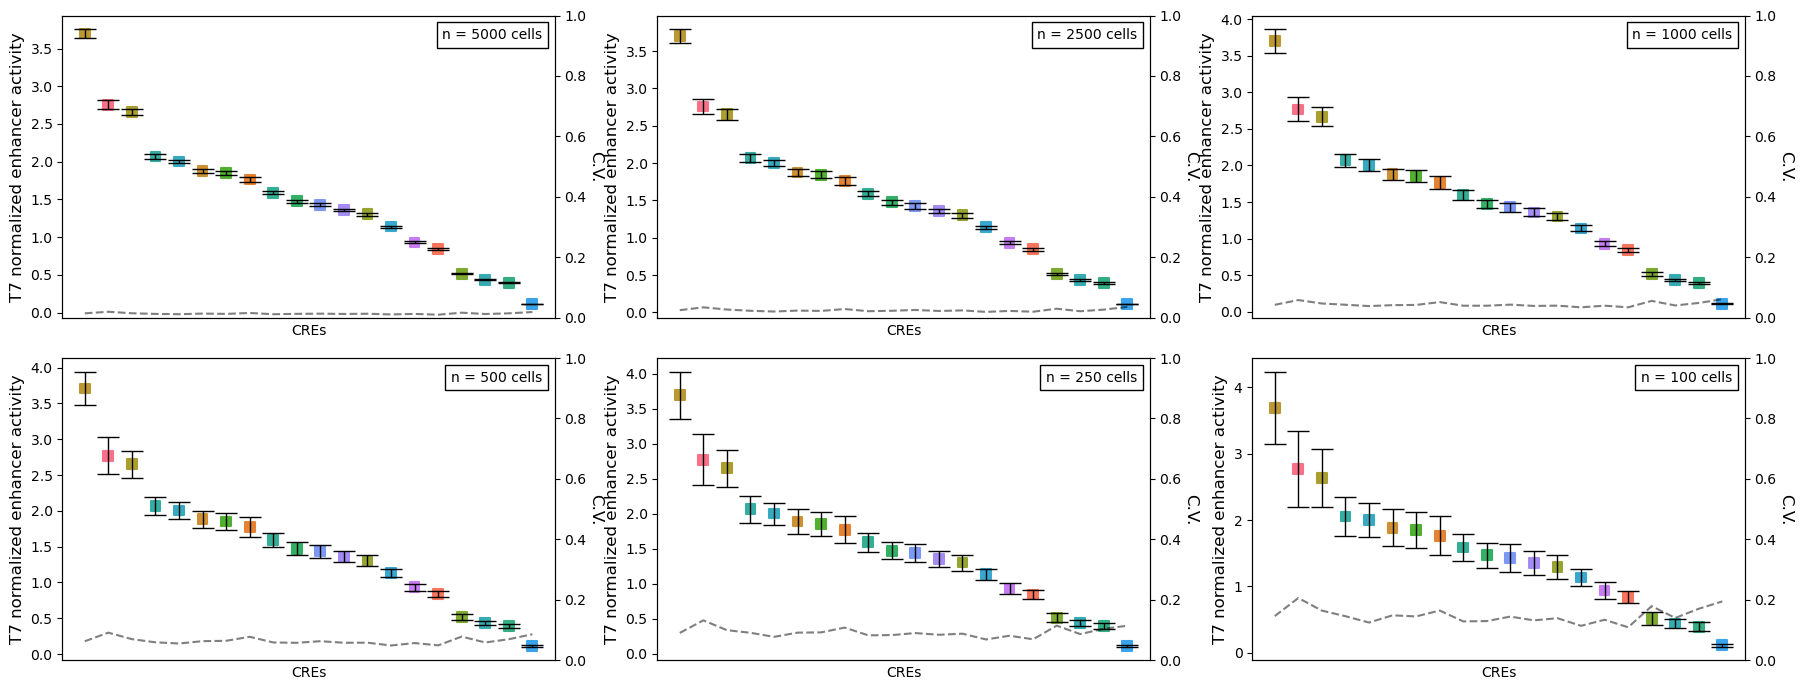

In [201]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText

# List of DataFrames and their corresponding names
dataframes = [df5000, df2500, df1000, df500, df250, df100]
df_names = ['5000 cells', '2500 cells', '1000 cells', '500 cells', '250 cells', '100 cells']

# Create a 2x3 grid of subplots
fig, axs = plt.subplots(2, 3, figsize=(18, 7))

# Loop through DataFrames and plot each
for i, (df, name) in enumerate(zip(dataframes, df_names)):
    row, col = divmod(i, 3)  # Calculate row and column index for the subplot
    ax = axs[row, col]
    
    # Scatter plot with error bars
    ax.scatter(range(0, 20), df.iloc[-3,:20], marker='s', c=[colors[i] for i in df.columns[:20]], s=50, lw=1.5)
    ax.errorbar(range(0, 20), df.iloc[-3,:20], df.iloc[-2,:20], linestyle='', linewidth=1, capsize=8, mew=1, ecolor='k')
    ax.set_ylabel('T7 normalized enhancer activity', fontsize=12)
    ax.set_xlabel('CREs')
    ax.set_xticks([])
    
    # Create twin axis for CV plot
    ax_twin = ax.twinx()
    ax_twin.plot(range(0, 20), df.iloc[-1,:20], lw=1.5, c='k', linestyle='--', alpha=0.5, zorder=1)
    ax_twin.set_ylim(0, 1)
    ax_twin.set_ylabel('C.V.', fontsize=12, rotation=270, labelpad=12)
    
    # Add annotation for the number of cells
    anchored_text = AnchoredText(f"n = {name}", loc=1)
    ax.add_artist(anchored_text)

# Adjust the layout to prevent overlap
plt.tight_layout()

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_July_2024_analysis\downsampling_T7_normalized_250131.pdf')

# Show the plot
plt.show()